# Model Spikey observed by Kepler with jaxns

In this notebook we use the Bayesian inference package [`jaxns`](https://github.com/Joshuaalbert/jaxns), using nested sampling, to model the Kepler observation of Spikey, reduced by Smith+2016. 

In [1]:
%load_ext autoreload
%autoreload 2

In [1]:
# Built-in
import os
import sys
import json
import copy
import datetime

# Dependencies
import scipy
import numpy as np
import pandas as pd
from astropy import constants as c
from pathlib import Path
from functools import partial

# jax/numpyro/jaxns
import jax
jax.config.update("jax_enable_x64", True)
from jax import random
from jax import numpy as jnp
import numpyro
import numpyro.distributions as dist
from numpyro.contrib.nested_sampling import NestedSampler
from jaxns import summary
numpyro.enable_x64()
numpyro.set_host_device_count(4)

# Internal methods
sys.path.append('../src')
from smbhb_jax import smbhb_jax
import smbhb as smbhb
import bayes as bs
import utils as ut
import plots as pt
pt.setup()

/home/phuijse/Work/PLATO_spikey/.venv/lib/python3.13/site-packages/astropy/config/paths.py:55: AstropyUserWarning: XDG_CONFIG_HOME is set to '/home/phuijse/.config', but the default location, /home/phuijse/.astropy/config, already exists, and takes precedence. This environment variable will be ignored.
  return set_temp_config._get_dir_path(rootname)
INFO:2026-01-23 16:56:17,121:jax._src.xla_bridge:810: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
INFO:jax._src.xla_bridge:Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory


In [3]:
# Global paths
path = Path('../')
ddir = path / 'data'
rdir = path / 'results'

---
## 1. Modelling DM light curve ala Hu+2020
---

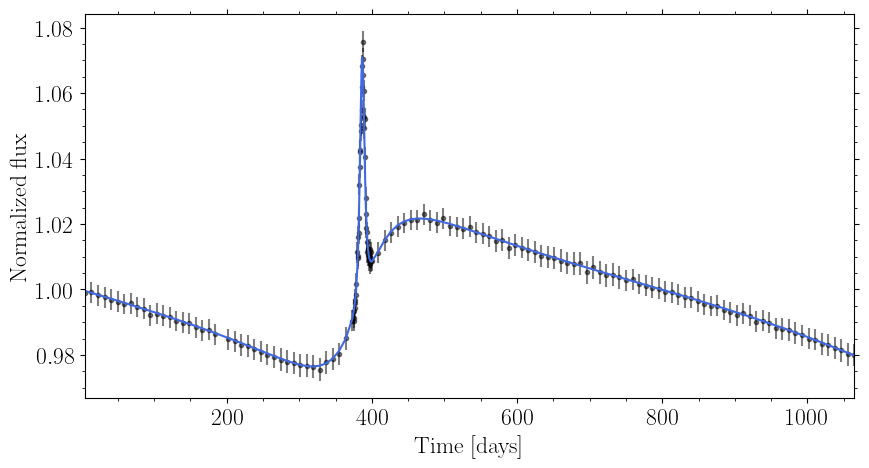

In [4]:
# Load Hu+2020 binned light curve of Spikey 
df = pd.read_csv(ddir / 'data_spikey_DM_kepler_hu2020.csv')
time = df.time.to_numpy()

# Generate relativistic Spikey model
params = smbhb.model_params()
params.sigma = 0 
model = smbhb.model(params)
dm = model.light_curve(time, df=True)

# Normalize light curve to model
df.flux = df.flux * dm.flux.median() / df.flux.median()

# Plot light curve
pt.plot_lc(df, dm);

---
### 1.1. Parameterization with `logM1` and `logM2`

In [5]:
values = {'t0': params.t0, 'P': params.P, 'i': params.i, 'e': params.e, 'w': params.w, 'logM1': params.logM1, 'logM2': params.logM2, 'L': params.L, 'alpha': params.alpha}

#### *1.1.1. Uniform priors*

In [6]:
%%time

def drop_pred_params(results):
    """
    Drop the quantiles of the predictive posterior (we only want to see the model parameters here)
    """
    filtered_samples = {
        k: v for k, v in results.samples.items()
        if not k.startswith("pred_")
    }
    return results._replace(samples=filtered_samples)


priors = {
    'logM1': dist.Uniform(6, 11),
    'logM2': dist.Uniform(6, 11),
    'L': dist.Uniform(0, 1),
    'e': dist.Uniform(0, 1),
    'w': dist.Uniform(0, 360),
    'i': dist.Uniform(0, 90),
    'alpha': dist.Uniform(-4, 4),
    'P': dist.Uniform(0, 5),
    't0': dist.Uniform(0, 1000/365),
    'z': params.z,
    'vz': params.vz,
}

ns = NestedSampler(bs.make_tinygp_model(priors=priors, build_kernel=None, build_mean=bs.smbhb_mean_builder), constructor_kwargs={
    'num_live_points': 2000, 'max_samples': 100_000, 'verbose': False, 'init_efficiency_threshold': 0.1,
    'gradient_guided': False, 'parameter_estimation': False, 'difficult_model': True
})
rng_key, rng_key2 = random.split(random.PRNGKey(1234))
jax_time = jnp.asarray(df['time'])
jax_flux = jnp.asarray(df['flux'])
jax_ferr = jnp.asarray(df['flux_err'])
time_interp = jnp.linspace(jnp.amin(time), jnp.amax(time), 500)
ns.run(rng_key, x=jax_time, y=jax_flux, yerr=jax_ferr, x_interp=time_interp)
summary(drop_pred_params(ns._results))
ns_samples = ns.get_samples(rng_key2, num_samples=10_000)

INFO:jaxns:Number of Markov-chains set to: 2000


--------
Termination Conditions:
Small remaining evidence
--------
likelihood evals: 68434673
samples: 78000
phantom samples: 0
likelihood evals / sample: 877.4
phantom fraction (%): 0.0%
--------
logZ=718.3 +- 0.16
max(logL)=756.78
H=-34.63
ESS=4862
--------
L: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
L: 0.38 +- 0.29 | 0.04 / 0.32 / 0.78 | 0.01 | 0.01
--------
P: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
P: 1.142 +- 0.014 | 1.124 / 1.141 / 1.16 | 1.141 | 1.141
--------
alpha: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
alpha: 1.83 +- 0.4 | 1.12 / 1.97 / 2.15 | 2.22 | 2.22
--------
e: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
e: 0.508 +- 0.016 | 0.489 / 0.508 / 0.529 | 0.51 | 0.51
--------
i: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
i: 82.29 +- 0.54 | 81.57 / 82.31 / 82.97 | 81.96 | 81.96
--------
logM1: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP

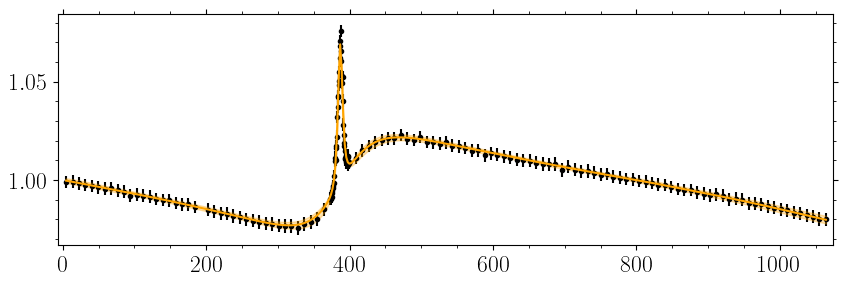

In [7]:
from matplotlib import pyplot as plt

fig, ax = plt.subplots(figsize=(10, 3))
ax.errorbar(df.time, df.flux, yerr=df.flux_err, fmt='.k', zorder=1)
pt.predictive_posterior_drw(ax, samples=ns_samples, x=time_interp)

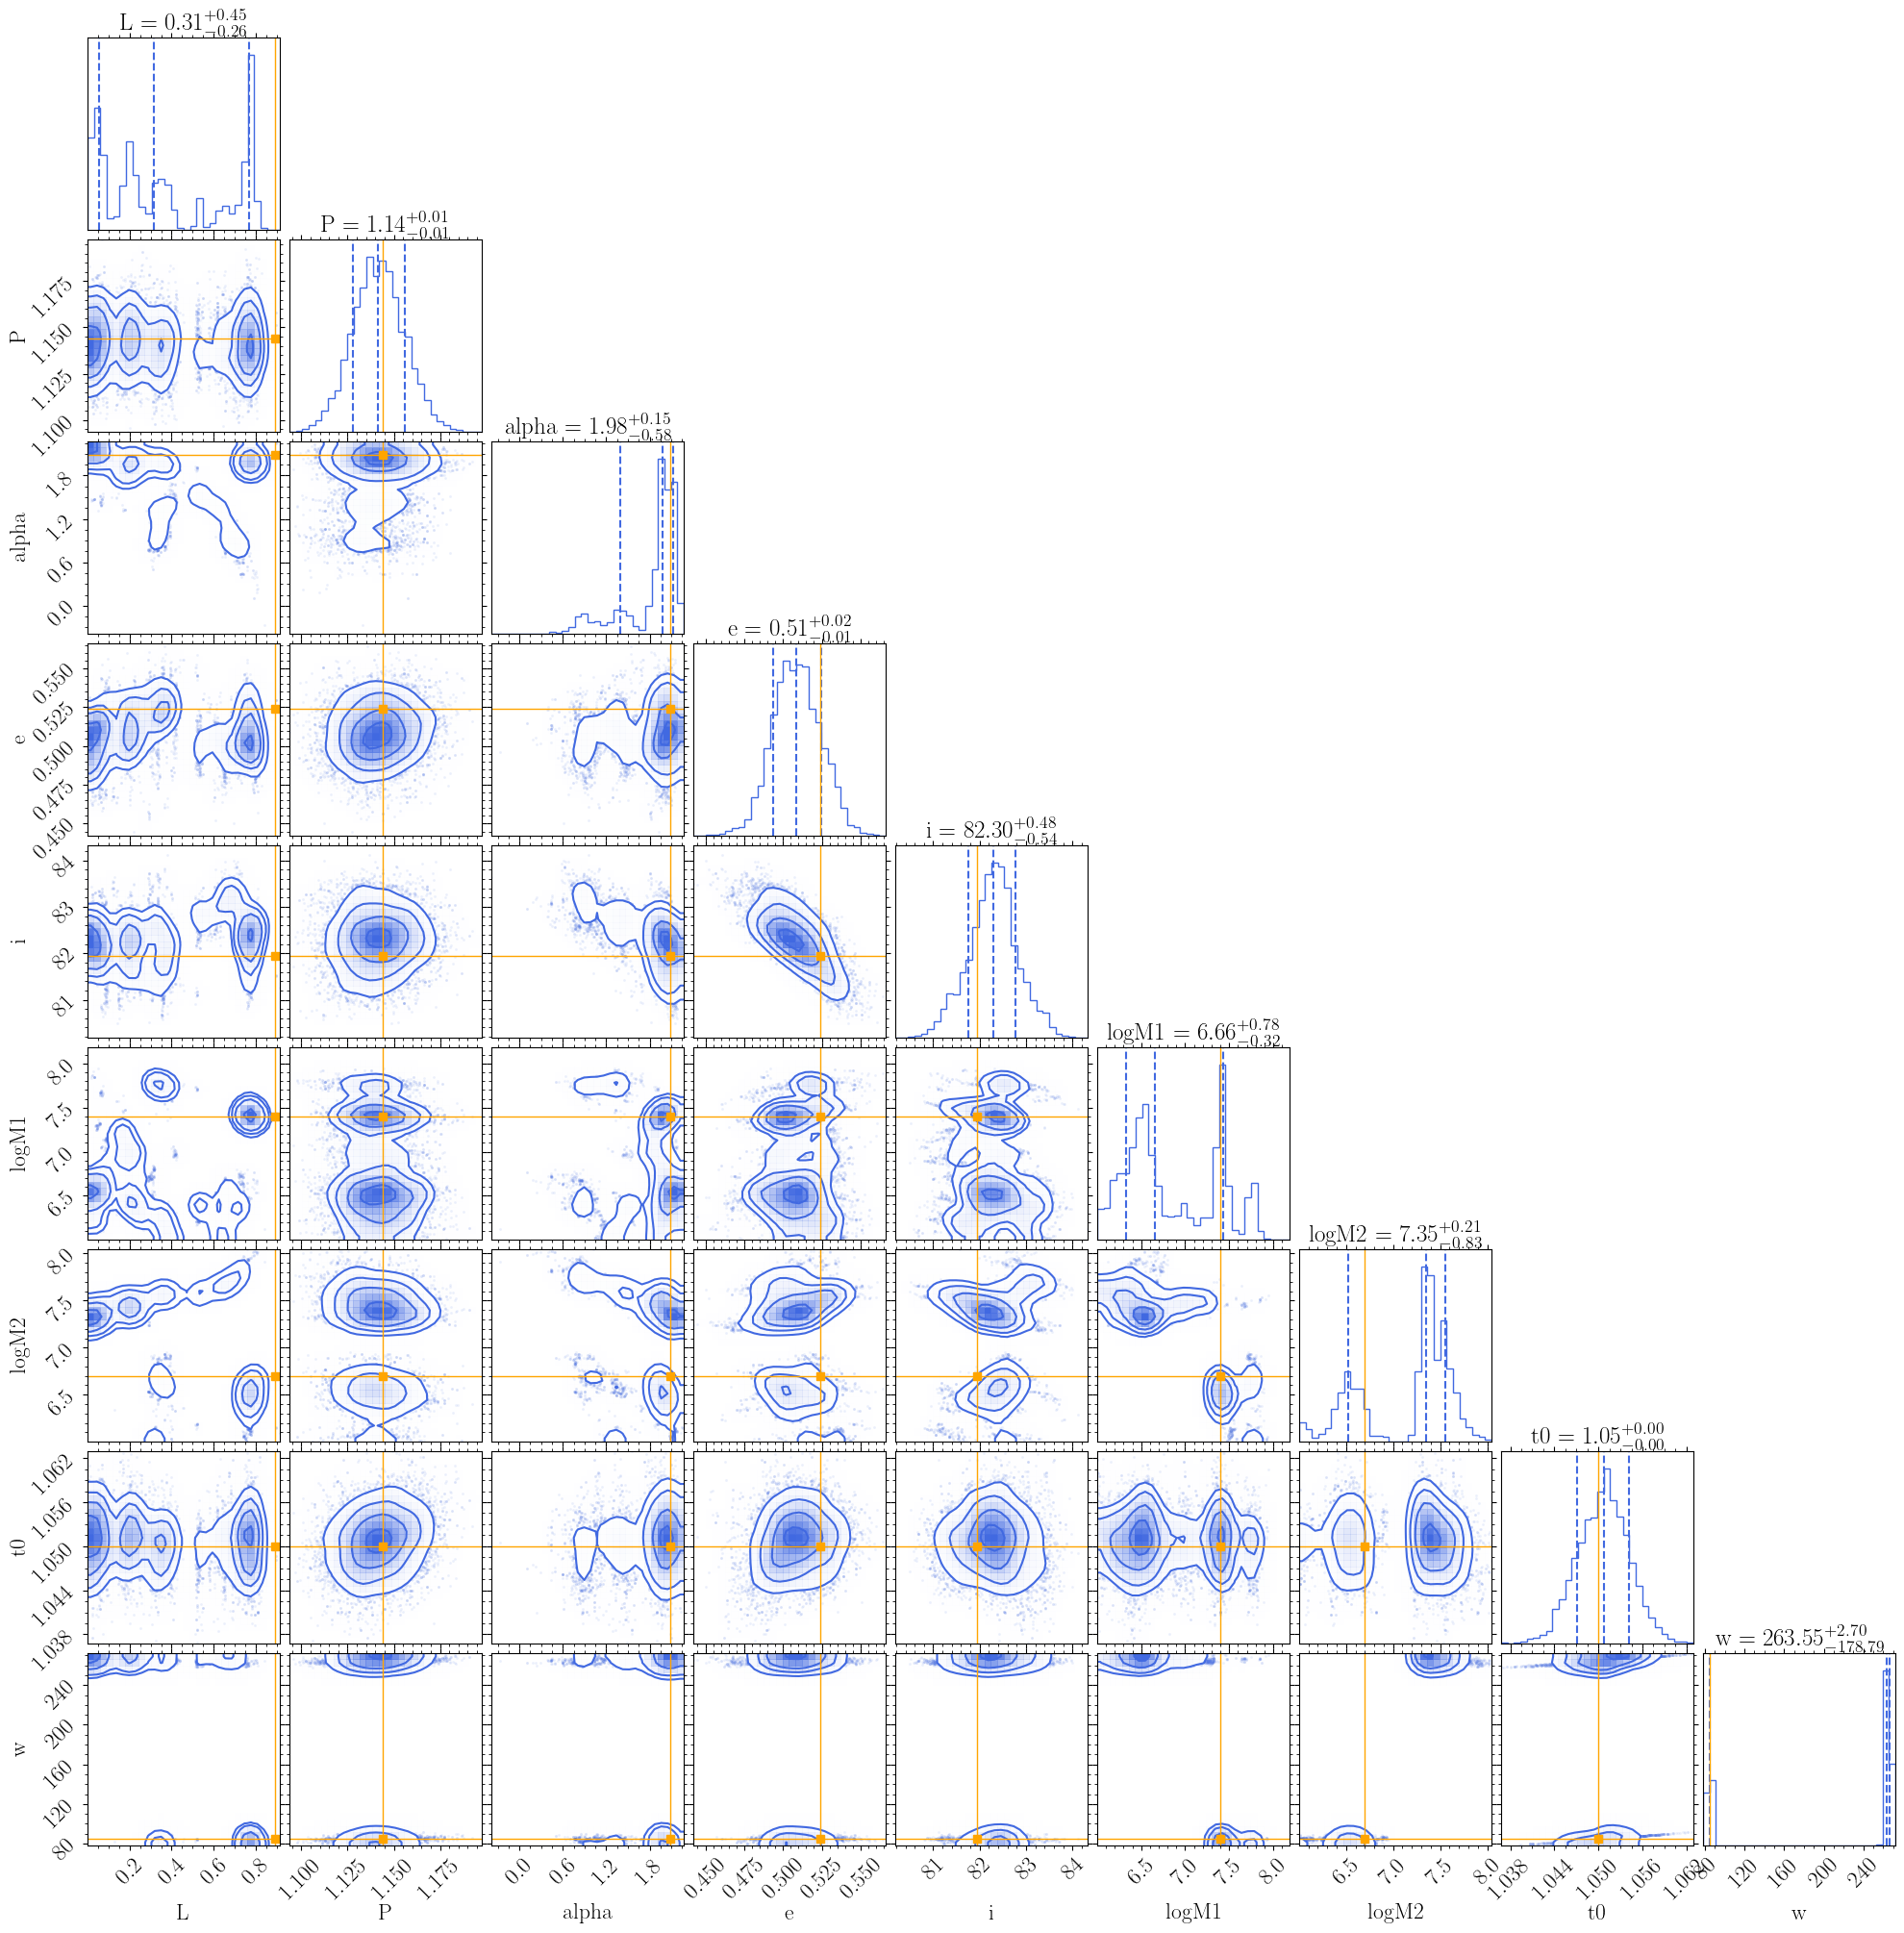

In [8]:
pt.plot_corner_mcmc(samples={k: np.asarray(v) for k, v in ns_samples.items()}, true_params=[values[k] for k in ns_samples.keys() if 'pred' not in k]);

Inspect the two modes by splitting `w`

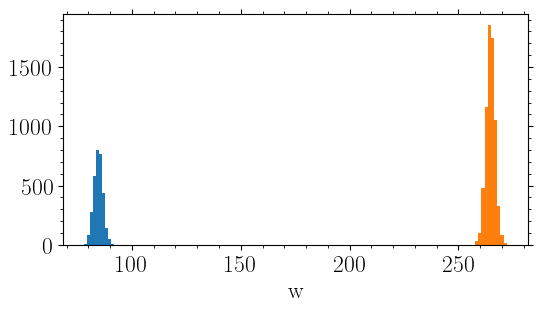

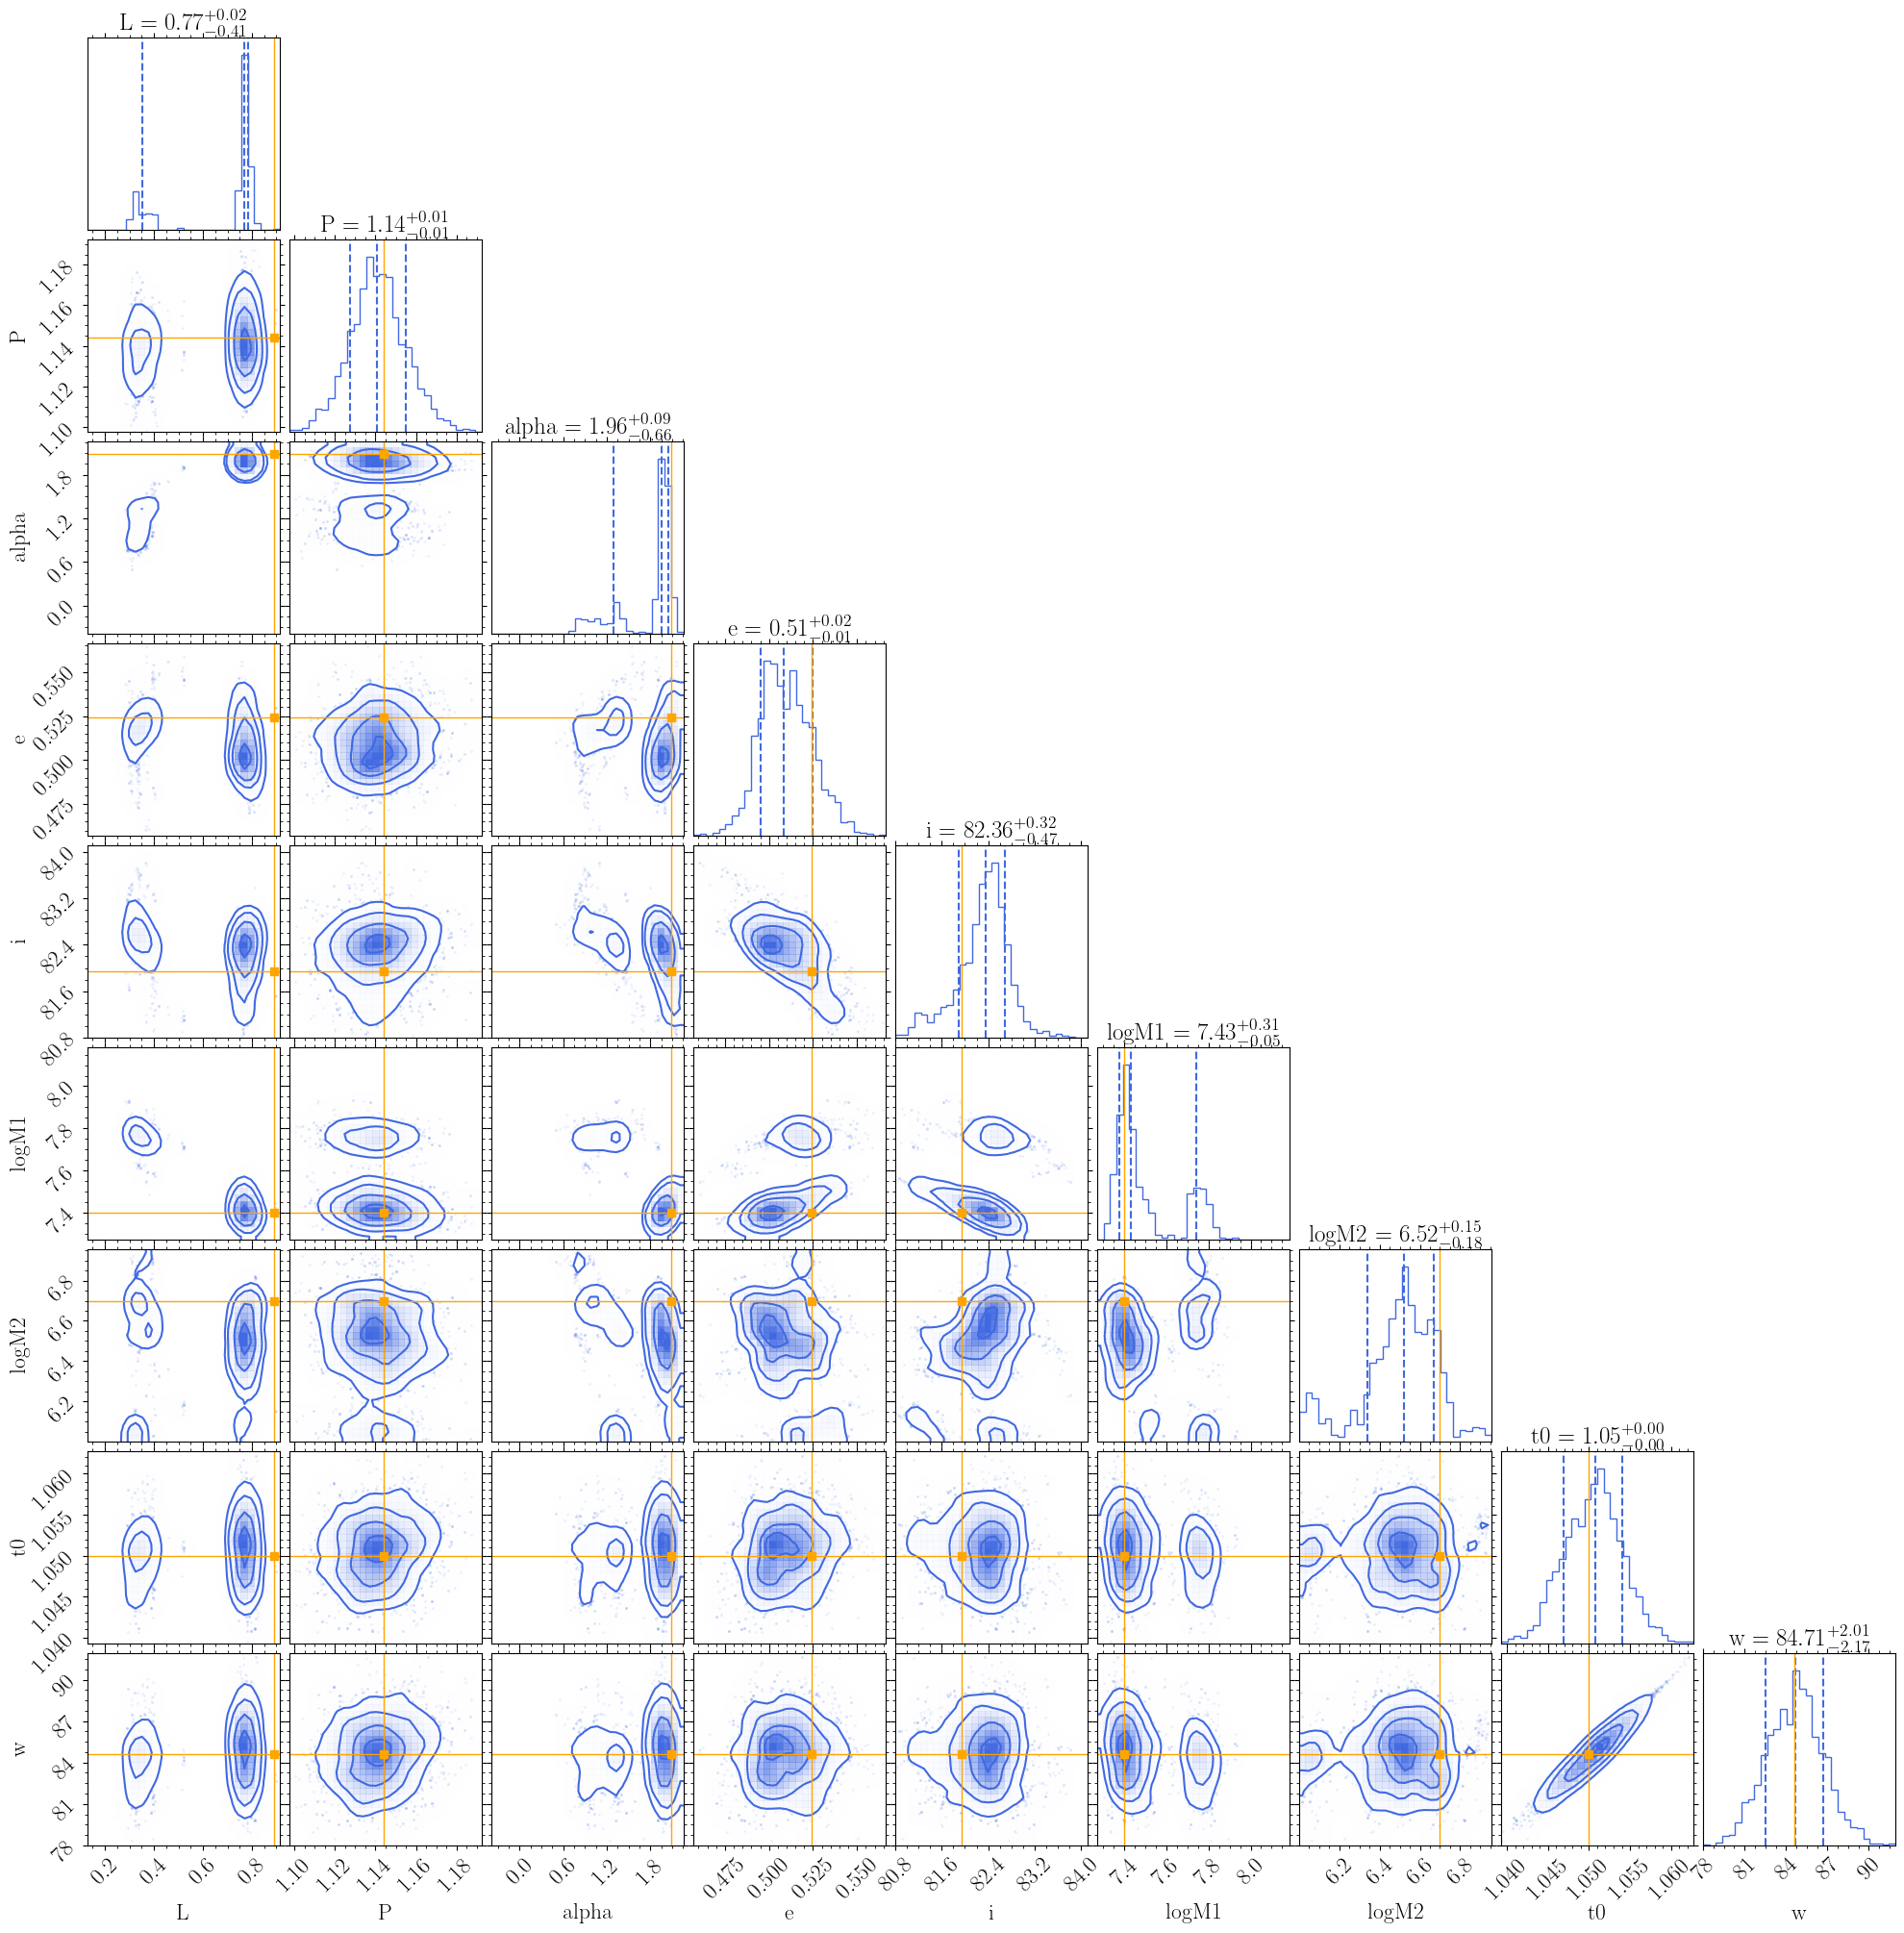

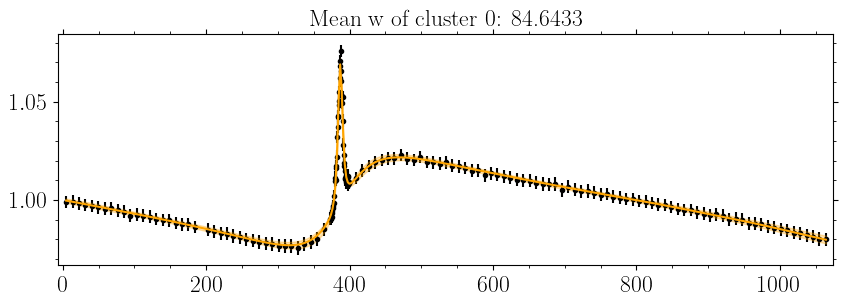

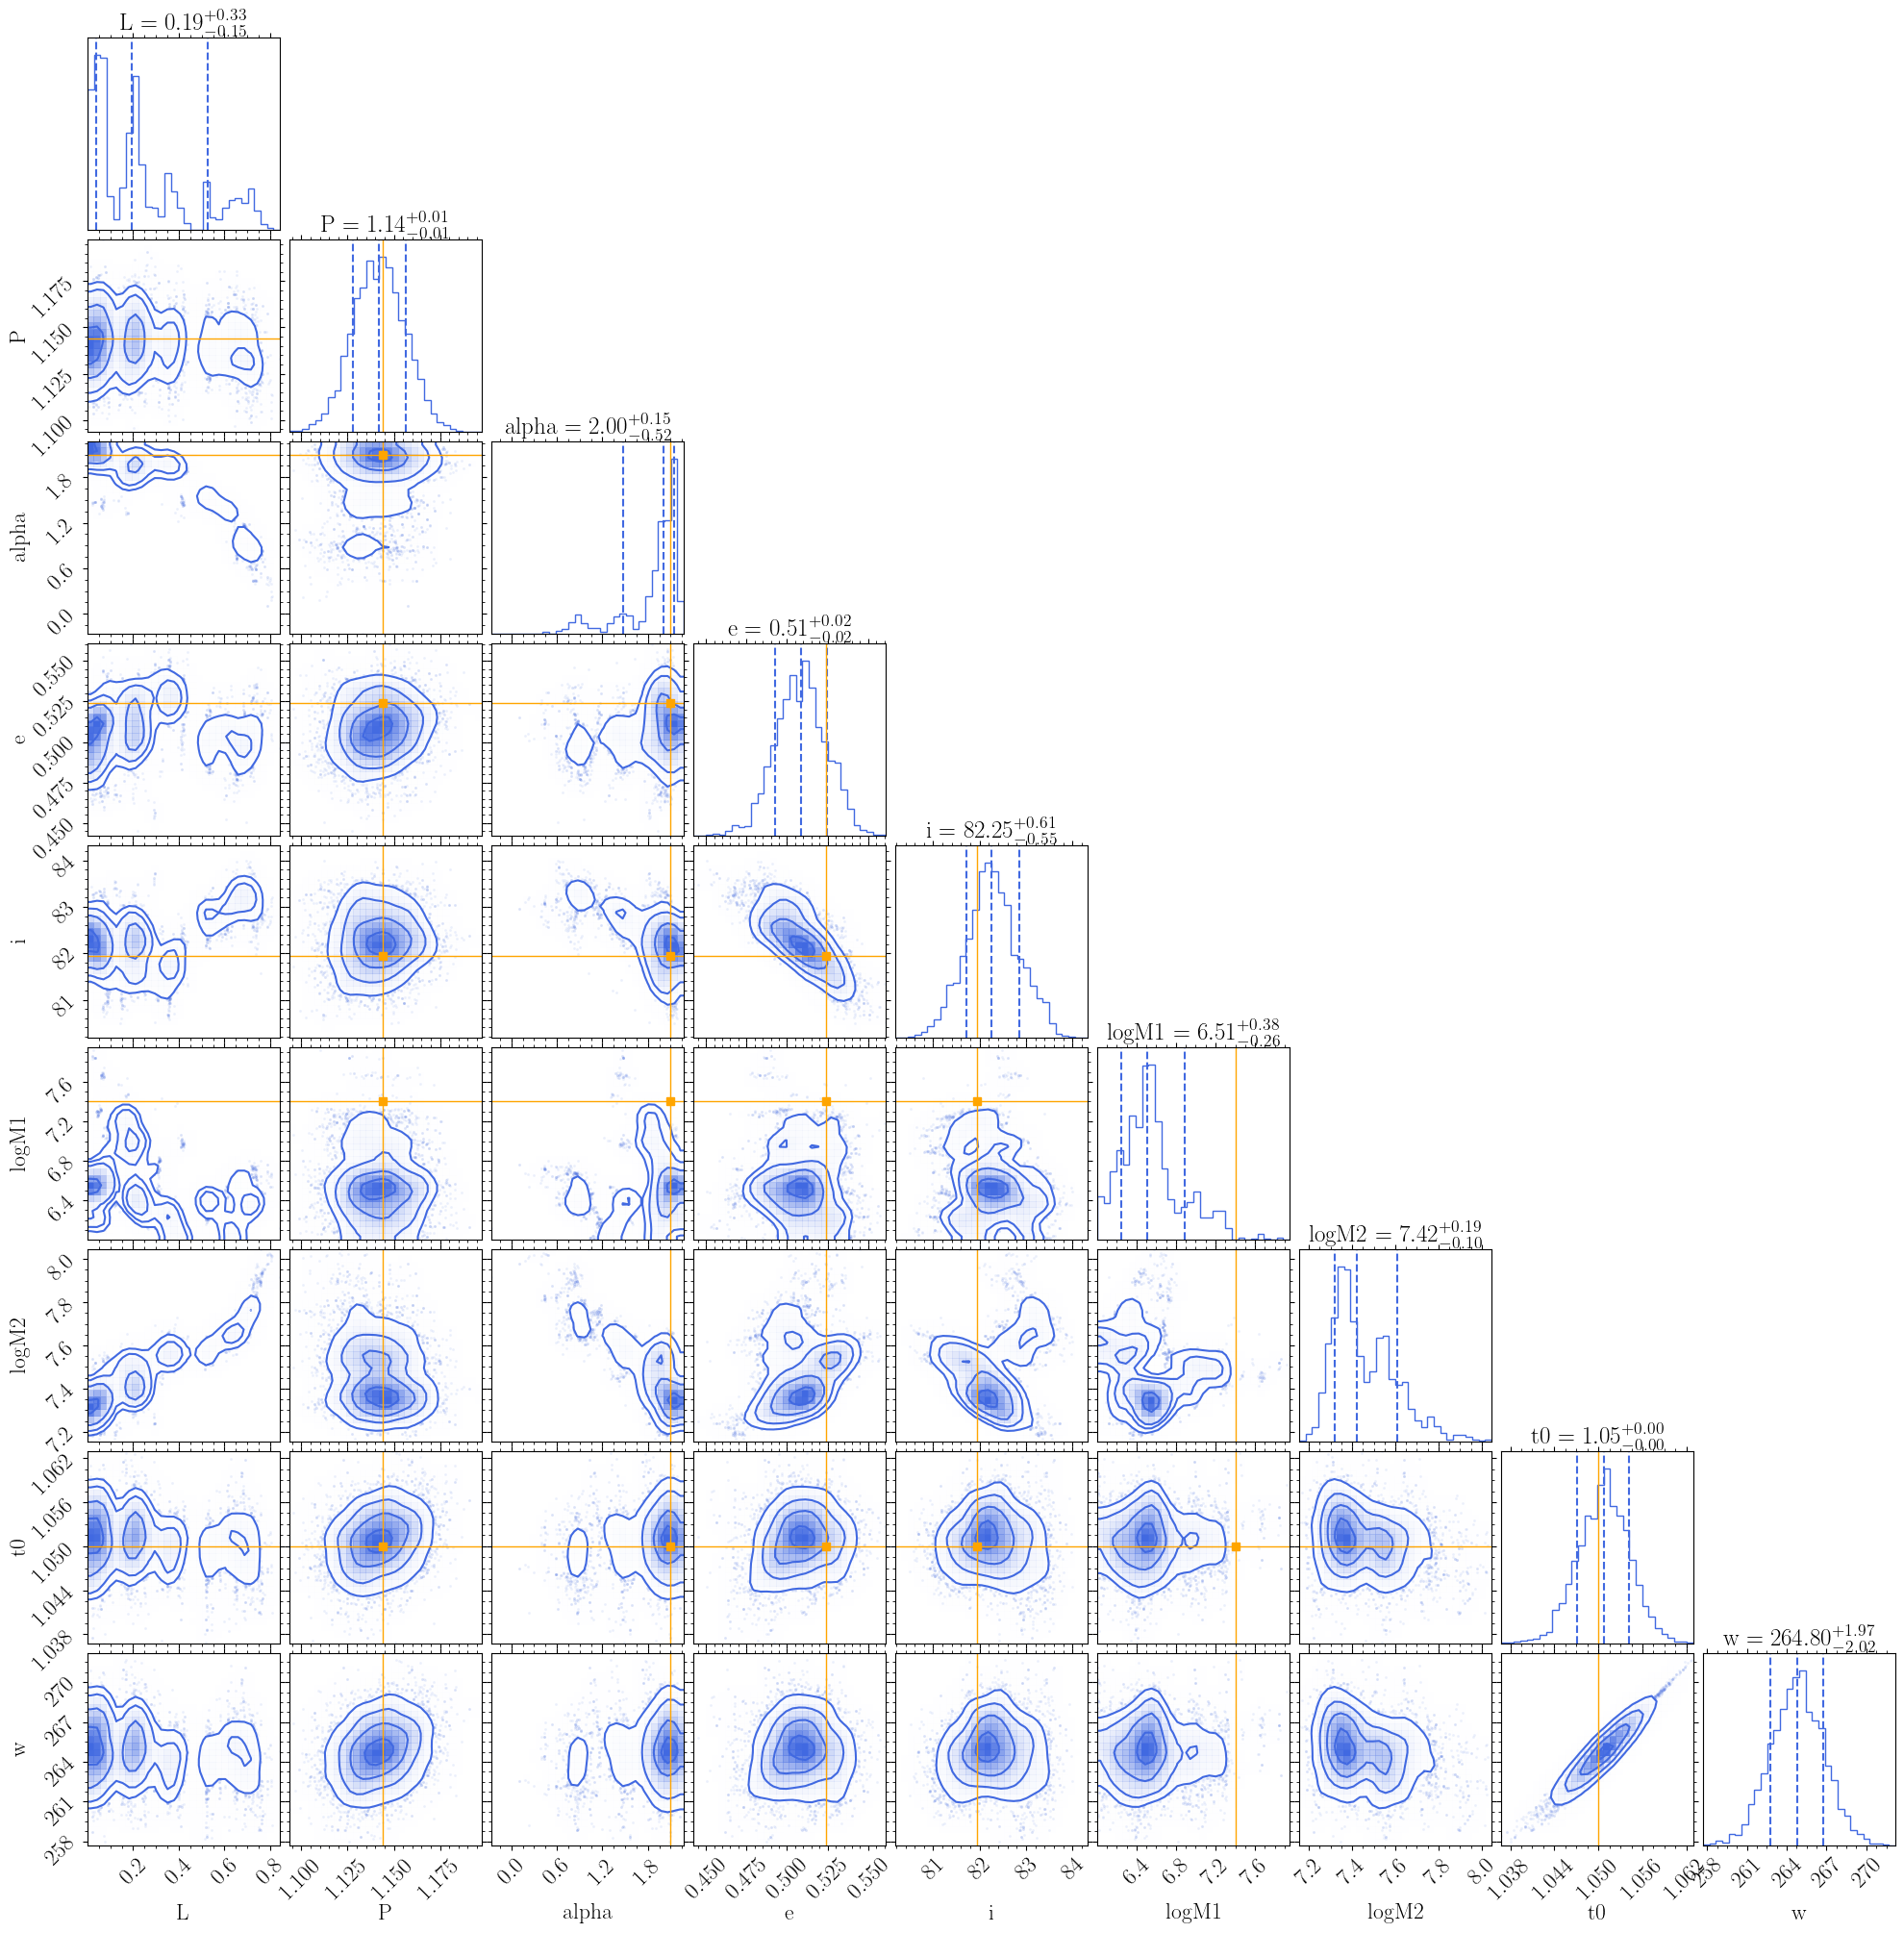

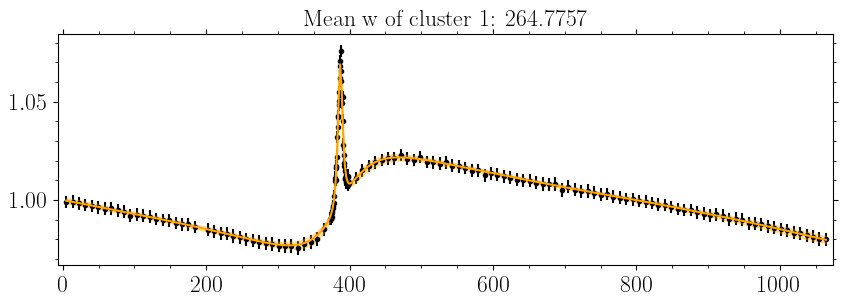

In [9]:
from sklearn.mixture import GaussianMixture

param_cluster = 'w'
cluster_model = GaussianMixture(n_components=2)
respons = cluster_model.fit_predict(ns_samples[param_cluster].reshape(-1, 1))
fig, ax = plt.subplots(figsize=(6, 3))
for k in range(cluster_model.n_components):
    ax.hist(ns_samples[param_cluster][respons==k])
ax.set_xlabel(param_cluster)

for c in range(cluster_model.n_components):
    sub_samples = {k: v[respons==c] for k, v in ns_samples.items()}
    pt.plot_corner_mcmc(samples={k: np.asarray(v) for k, v in sub_samples.items()}, true_params=[values[k] for k in sub_samples.keys() if 'pred' not in k]);
    fig, ax = plt.subplots(figsize=(10, 3))
    ax.errorbar(df.time, df.flux, yerr=df.flux_err, fmt='.k', zorder=1)
    pt.predictive_posterior_drw(ax, samples=sub_samples, x=time_interp)
    ax.set_title(f"Mean {param_cluster} of cluster {c}: {ns_samples[param_cluster][respons==c].mean():0.4f}")

---
### 1.2. Parameterization using `logM` and `q`

In [ ]:
# Generate relativistic Spikey model
params = smbhb.model_params_q()
params.sigma = 0 
model = smbhb.model_q(params)
dm = model.light_curve(time, df=True)
values = [params.t0, params.P, params.i, params.e, params.w, params.logM, params.q, params.L, params.alpha]

#### *1.1.1. Uniform priors*